In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -qU ultralytics supervision

In [ ]:
from ultralytics import YOLO
# import albumentations as A
# from albumentations.pytorch import ToTensorV2
import cv2
# from tqdm import tqdm
import os
import numpy as numpy
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


##Load Dataset

In [ ]:
import os
# HOME = os.getcwd()
HOME = ('/content/drive/MyDrive/purwadhika/Module 4/capstone4')

os.chdir(HOME)

In [ ]:
dataset_location = "./vehicle-detection.v1i.yolov12"

In [ ]:
!ls {dataset_location}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!cat {dataset_location}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['bus', 'car', 'van']

roboflow:
  workspace: personal-project-kej16
  project: vehicle-detection-vznzd-dkl8g
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/personal-project-kej16/vehicle-detection-vznzd-dkl8g/dataset/1

##Preprocessing Data

In [ ]:
print("load data image")
folder_image = "./vehicle-detection.v1i.yolov12/train/images"
output_folder = "./preprocessing"
os.makedirs(output_folder, exist_ok=True)
print("preprocessing data")
for img_name in os.listdir(folder_image):
    path_image = os.path.join(folder_image, img_name)
    image = cv2.imread(path_image)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(image_rgb, (int(image_rgb.shape[0]/2), (int(image_rgb.shape[1]/2))))

    save_path = os.path.join(output_folder, img_name)
    cv2.imwrite(save_path, resized)

print("Selesai menyimpan preprocessing semua gambar.")

load data image
preprocessing data


In [ ]:
os.listdir(len("./preprocessing"))

NotADirectoryError: [Errno 20] Not a directory: 15

##Pretraining Model

In [ ]:
!wget https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt

--2026-06-17 19:02:44--  https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/928546208/99db71db-0946-4c10-94a0-b54baf471037?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-17T20%3A01%3A32Z&rscd=attachment%3B+filename%3Dyolov12n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-06-17T19%3A01%3A29Z&ske=2026-06-17T20%3A01%3A32Z&sks=b&skv=2018-11-09&sig=1ixaW6QuLq4iVBNm%2FWEPpONE8UED4Vf6xQ7wRULi3%2Fw%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MTcyMzI2NCwibmJmIjoxNzgxNzIyOTY0LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLm

In [ ]:
model_name = "yolov12n.pt"

In [ ]:
model = YOLO(model_name)
results = model.train(
    data="./vehicle-detection.v1i.yolov12/data2.yaml",
    epochs=5,
    imgsz=640,
    batch=16,
    exist_ok=True,
    patience=5,
    save_period=5,
    val=True,
    verbose=True
)
print("selesai print model")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./vehicle-detection.v1i.yolov12/data2.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

In [34]:
metrics = model.val()

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 1.1±0.6 ms, read: 5.8±4.8 MB/s, size: 26.1 KB)
val: Scanning /content/drive/MyDrive/purwadhika/Module 4/capstone4/vehicle-detection.v1i.yolov12/valid/labels.cache... 287 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 287/287 10.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 19, len(boxes) = 427. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 6.0s/it 1:48
                   all        287        427   0.000824      0.154   0.000214   3.82e-05
                   bus         67        113   0.000775      0.186  

In [35]:
print(metrics.box.map)
print(metrics.box.map50)
print(metrics.box.map75)

3.818710407708272e-05
0.00021435724553713946
1.0743776283881264e-06


In [64]:
model_name = "./yolov12n.pt"
model = YOLO(model_name)

In [65]:
results = model("./street.jpg")


image 1/1 /content/drive/MyDrive/purwadhika/Module 4/capstone4/street.jpg: 448x640 2 cars, 3 buss, 201.3ms
Speed: 13.1ms preprocess, 201.3ms inference, 3.3ms postprocess per image at shape (1, 3, 448, 640)


In [66]:
from collections import Counter

result = results[0]

class_names = result.names

counter = Counter()

for cls in result.boxes.cls:
    label = class_names[int(cls)]
    counter[label] += 1

print(counter)

Counter({'bus': 3, 'car': 2})


In [67]:
for kendaraan, jumlah in counter.items():
    print(f"{kendaraan}: {jumlah}")

bus: 3
car: 2


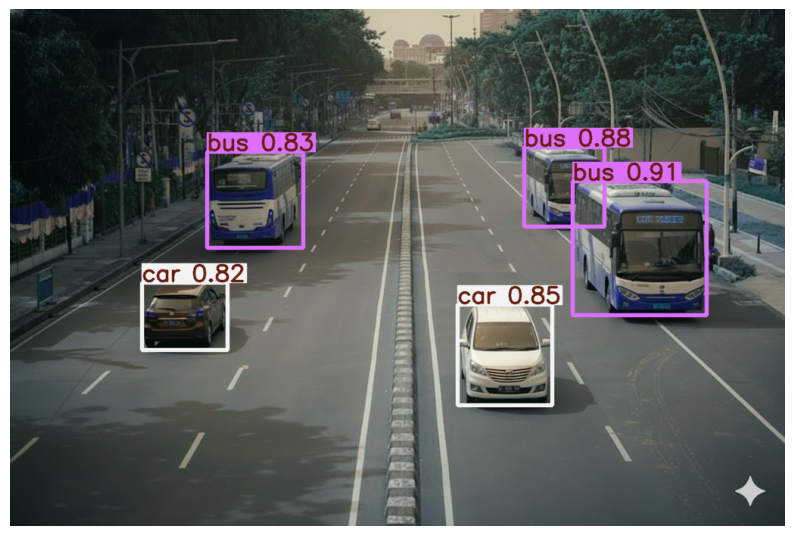

In [68]:
import matplotlib.pyplot as plt

result = results[0]

annotated = result.plot()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(annotated)
plt.axis("off")
plt.show()